In [1]:
import numpy as np
import pandas as pd
from scipy import stats

# This file calculates the cumulative validator exits after the Ethereum Staking Withdrawals Open

In [2]:
validator_exits_size = pd.read_csv('../int/validator_exits_size.csv').drop(columns=(['total']))
validator_exits_category = pd.read_csv('../int/validator_exits_category.csv').drop(columns=(['total', 'Unidentified']))
active_validators_size = pd.read_csv('../int/active_validators_size.csv')
active_validators_category = pd.read_csv('../int/active_validators_category.csv')

active_validators_size = active_validators_size[active_validators_size['slot']==6202800]
active_validators_size = active_validators_size.drop(columns=(['total']))
active_validators_category = active_validators_category[active_validators_category['slot']==6202800]
active_validators_category = active_validators_category.drop(columns=(['total', 'Unidentified']))
active_validators_category

,slot,CEX,Liquid Restaking,Liquid Staking,Solo Stakers,Staking Pools,Unnamed: 7
6202800,6202800.0,186774.0,8.0,202992.0,1761.0,3514.0,0.0


In [3]:
validator_exits_size = validator_exits_size[validator_exits_size['slot']>=6202800]
validator_exits_category = validator_exits_category[validator_exits_category['slot']>=6202800]

In [4]:
validator_exits_size_set = validator_exits_size
validator_exits_size_set['slot'] = validator_exits_size_set['slot'] // 300 * 300

# Group by the day and get the last slot of each day and sum values for all columns
validator_exits_size_set = validator_exits_size_set.groupby('slot').agg(
    {
        'slot': 'last',
        '1': 'sum',
        '2-5': 'sum',
        '6-19': 'sum',
        '20-99': 'sum',
        '100+': 'sum',
    }
).reset_index(drop=True)

validator_exits_size_set

,slot,1,2-5,6-19,20-99,100+
0,6202800.0,0.0,0.0,0.0,0.0,0.0
1,6203100.0,0.0,0.0,0.0,0.0,1.0
2,6203400.0,0.0,0.0,0.0,0.0,0.0
3,6203700.0,0.0,0.0,0.0,0.0,0.0
4,6204000.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...
9273,8984700.0,3.0,0.0,0.0,0.0,83.0
9274,8985000.0,0.0,0.0,0.0,0.0,12.0
9275,8985300.0,0.0,0.0,0.0,0.0,6.0
9276,8985600.0,1.0,0.0,0.0,0.0,0.0


In [5]:
validator_exits_category_set = validator_exits_category
validator_exits_category_set['slot'] = validator_exits_category_set['slot'] // 300 * 300

# Create a dictionary for aggregation
agg_dict = {col: 'sum' for col in validator_exits_category_set.columns if col != 'slot'}
agg_dict['slot'] = 'last'

# Group by 'slot' and apply the aggregation
validator_exits_category_set = validator_exits_category_set.groupby('slot').agg(agg_dict).reset_index(drop=True)

validator_exits_category_set

,CEX,Liquid Restaking,Liquid Staking,Solo Stakers,Staking Pools,Unnamed: 7,slot
0,0.0,0.0,0.0,0.0,0.0,0.0,6202800.0
1,0.0,0.0,1.0,0.0,0.0,0.0,6203100.0
2,0.0,0.0,0.0,0.0,0.0,0.0,6203400.0
3,0.0,0.0,0.0,0.0,0.0,0.0,6203700.0
4,0.0,0.0,0.0,0.0,0.0,0.0,6204000.0
...,...,...,...,...,...,...,...
9273,11.0,0.0,4.0,0.0,0.0,0.0,8984700.0
9274,0.0,0.0,3.0,0.0,0.0,0.0,8985000.0
9275,0.0,0.0,4.0,0.0,0.0,0.0,8985300.0
9276,0.0,0.0,0.0,0.0,0.0,0.0,8985600.0


In [6]:
# Add the slot column to active_validators_category and fill forward
active_validators_category = pd.merge(active_validators_category, validator_exits_category_set['slot'], on='slot', how='right')
active_validators_category = active_validators_category.ffill()
active_validators_category

,slot,CEX,Liquid Restaking,Liquid Staking,Solo Stakers,Staking Pools,Unnamed: 7
0,6202800.0,186774.0,8.0,202992.0,1761.0,3514.0,0.0
1,6203100.0,186774.0,8.0,202992.0,1761.0,3514.0,0.0
2,6203400.0,186774.0,8.0,202992.0,1761.0,3514.0,0.0
3,6203700.0,186774.0,8.0,202992.0,1761.0,3514.0,0.0
4,6204000.0,186774.0,8.0,202992.0,1761.0,3514.0,0.0
...,...,...,...,...,...,...,...
9273,8984700.0,186774.0,8.0,202992.0,1761.0,3514.0,0.0
9274,8985000.0,186774.0,8.0,202992.0,1761.0,3514.0,0.0
9275,8985300.0,186774.0,8.0,202992.0,1761.0,3514.0,0.0
9276,8985600.0,186774.0,8.0,202992.0,1761.0,3514.0,0.0


In [7]:
# Add the slot column to active_validators_size and fill forward
active_validators_size = pd.merge(active_validators_size, validator_exits_size_set['slot'], on='slot', how='right')
active_validators_size = active_validators_size.ffill()
active_validators_size

,slot,1,100+,2-5,20-99,6-19
0,6202800.0,6649.0,508415.0,8434.0,26629.0,12655.0
1,6203100.0,6649.0,508415.0,8434.0,26629.0,12655.0
2,6203400.0,6649.0,508415.0,8434.0,26629.0,12655.0
3,6203700.0,6649.0,508415.0,8434.0,26629.0,12655.0
4,6204000.0,6649.0,508415.0,8434.0,26629.0,12655.0
...,...,...,...,...,...,...
9273,8984700.0,6649.0,508415.0,8434.0,26629.0,12655.0
9274,8985000.0,6649.0,508415.0,8434.0,26629.0,12655.0
9275,8985300.0,6649.0,508415.0,8434.0,26629.0,12655.0
9276,8985600.0,6649.0,508415.0,8434.0,26629.0,12655.0


In [8]:
active_validators_category

,slot,CEX,Liquid Restaking,Liquid Staking,Solo Stakers,Staking Pools,Unnamed: 7
0,6202800.0,186774.0,8.0,202992.0,1761.0,3514.0,0.0
1,6203100.0,186774.0,8.0,202992.0,1761.0,3514.0,0.0
2,6203400.0,186774.0,8.0,202992.0,1761.0,3514.0,0.0
3,6203700.0,186774.0,8.0,202992.0,1761.0,3514.0,0.0
4,6204000.0,186774.0,8.0,202992.0,1761.0,3514.0,0.0
...,...,...,...,...,...,...,...
9273,8984700.0,186774.0,8.0,202992.0,1761.0,3514.0,0.0
9274,8985000.0,186774.0,8.0,202992.0,1761.0,3514.0,0.0
9275,8985300.0,186774.0,8.0,202992.0,1761.0,3514.0,0.0
9276,8985600.0,186774.0,8.0,202992.0,1761.0,3514.0,0.0


In [9]:
slots = validator_exits_category_set['slot']
validator_exits_category_set = validator_exits_category_set.drop(columns=('slot'))
active_validators_category = active_validators_category.drop(columns=('slot'))

In [10]:
validator_exits_category_set = validator_exits_category_set.divide(active_validators_category)
validator_exits_category_set = validator_exits_category_set



In [11]:
validator_exits_category_set['slot'] = slots

In [12]:
slots = validator_exits_size_set['slot']
validator_exits_size_set = validator_exits_size_set.drop(columns=('slot'))
active_validators_size = active_validators_size.drop(columns=('slot'))
validator_exits_size_set = validator_exits_size_set.divide(active_validators_size)
validator_exits_size_set

,1,100+,2-5,20-99,6-19
0,0.000000,0.000000,0.0,0.0,0.0
1,0.000000,0.000002,0.0,0.0,0.0
2,0.000000,0.000000,0.0,0.0,0.0
3,0.000000,0.000000,0.0,0.0,0.0
4,0.000000,0.000000,0.0,0.0,0.0
...,...,...,...,...,...
9273,0.000451,0.000163,0.0,0.0,0.0
9274,0.000000,0.000024,0.0,0.0,0.0
9275,0.000000,0.000012,0.0,0.0,0.0
9276,0.000150,0.000000,0.0,0.0,0.0


In [13]:
validator_exits_size_set = validator_exits_size_set
validator_exits_size_set['slot'] = slots
validator_exits_size_set = validator_exits_size_set[['1', '2-5', '6-19', '20-99', '100+', 'slot']]

In [14]:
validator_exits_size_set = validator_exits_size_set[validator_exits_size_set['slot'] <= 6404400]
validator_exits_category_set = validator_exits_category_set[validator_exits_category_set['slot'] <= 6404400]

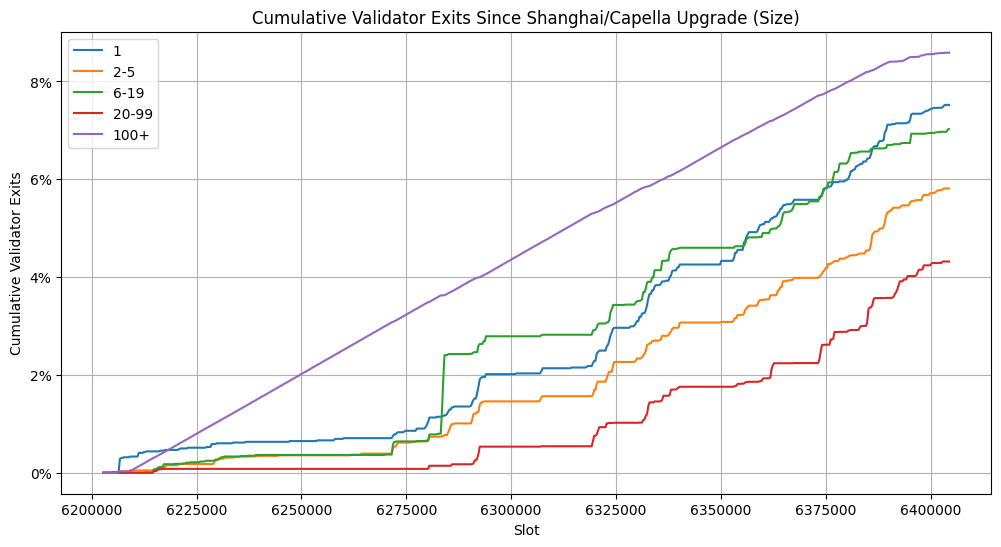

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Calculate cumulative sum for each column except 'slot'
cumulative_sum = validator_exits_size_set.iloc[:, :-1].cumsum()

# Add the 'slot' column back to the cumulative sum dataframe
cumulative_sum['slot'] = validator_exits_size_set['slot']

# Plot the cumulative sum for each size by slot
plt.figure(figsize=(12, 6))
for column in cumulative_sum.columns[:-1]:
    plt.plot(cumulative_sum['slot'], cumulative_sum[column], label=column)

plt.xlabel('Slot')
plt.ylabel('Cumulative Validator Exits')
plt.title('Cumulative Validator Exits Since Shanghai/Capella Upgrade (Size)')
plt.legend()
plt.grid(True)

# Format y-axis labels as percentages
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# Disable scientific notation for x-axis
ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useOffset=False))
ax.xaxis.get_major_formatter().set_scientific(False)

plt.show()



In [16]:
cumulative_sum

,1,2-5,6-19,20-99,100+,slot
0,0.000000,0.000000,0.000000,0.000000,0.000000,6202800.0
1,0.000000,0.000000,0.000000,0.000000,0.000002,6203100.0
2,0.000000,0.000000,0.000000,0.000000,0.000002,6203400.0
3,0.000000,0.000000,0.000000,0.000000,0.000002,6203700.0
4,0.000000,0.000000,0.000000,0.000000,0.000002,6204000.0
...,...,...,...,...,...,...
668,0.075049,0.058098,0.069696,0.043186,0.085816,6403200.0
669,0.075199,0.058098,0.069696,0.043186,0.085863,6403500.0
670,0.075199,0.058098,0.069696,0.043186,0.085863,6403800.0
671,0.075199,0.058098,0.070170,0.043186,0.085863,6404100.0


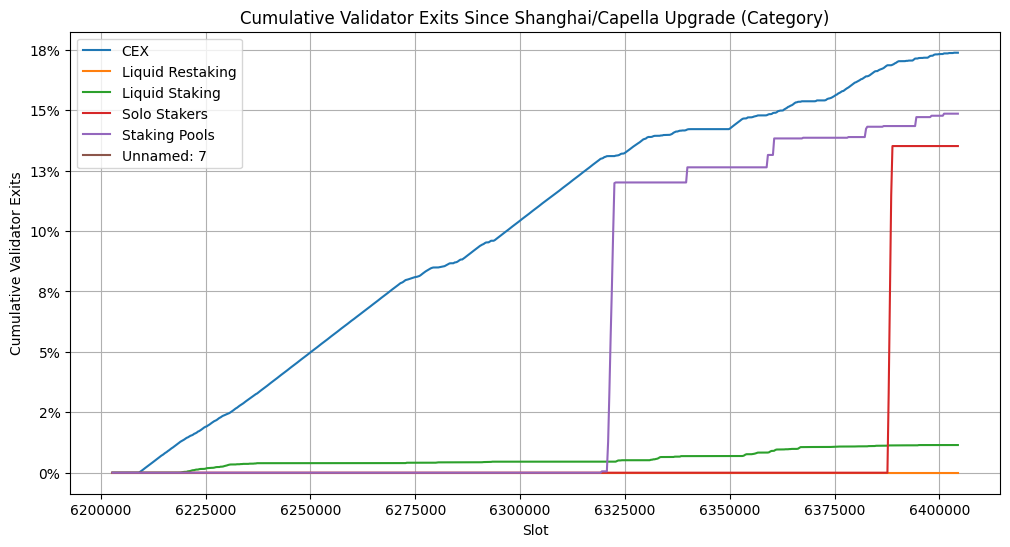

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Calculate cumulative sum for each column except 'slot'
cumulative_sum = validator_exits_category_set.iloc[:, :-1].cumsum()

# Add the 'slot' column back to the cumulative sum dataframe
cumulative_sum['slot'] = validator_exits_category_set['slot']

# Plot the cumulative sum for each size by slot
plt.figure(figsize=(12, 6))
for column in cumulative_sum.columns[:-1]:
    plt.plot(cumulative_sum['slot'], cumulative_sum[column], label=column)

plt.xlabel('Slot')
plt.ylabel('Cumulative Validator Exits')
plt.title('Cumulative Validator Exits Since Shanghai/Capella Upgrade (Category)')
plt.legend()
plt.grid(True)

# Format y-axis labels as percentages
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# Disable scientific notation for x-axis
ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useOffset=False))
ax.xaxis.get_major_formatter().set_scientific(False)

plt.show()

In [18]:
cumulative_sum

,CEX,Liquid Restaking,Liquid Staking,Solo Stakers,Staking Pools,Unnamed: 7,slot
0,0.000000,0.0,0.000000,0.00000,0.000000,NaN,6202800.0
1,0.000000,0.0,0.000005,0.00000,0.000000,NaN,6203100.0
2,0.000000,0.0,0.000005,0.00000,0.000000,NaN,6203400.0
3,0.000000,0.0,0.000005,0.00000,0.000000,NaN,6203700.0
4,0.000000,0.0,0.000005,0.00000,0.000000,NaN,6204000.0
...,...,...,...,...,...,...,...
668,0.173638,0.0,0.011454,0.13515,0.148549,NaN,6403200.0
669,0.173766,0.0,0.011454,0.13515,0.148549,NaN,6403500.0
670,0.173766,0.0,0.011454,0.13515,0.148549,NaN,6403800.0
671,0.173766,0.0,0.011454,0.13515,0.148549,NaN,6404100.0
